In [47]:
import os, sys

import torch
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

sys.path.append("../../code")

In [48]:
X, Y = torch.load("FashionMNIST/fashion_train_100.pt")
print(f"Shapes: X->{X.shape}")
print(f"        Y->{Y.shape}")

Shapes: X->torch.Size([60000, 100])
        Y->torch.Size([60000])


In [58]:
%%time
classes = np.unique(Y.detach().numpy())

stats = {}
for label in classes:
    same_label_X = X[Y==label]
    mean, std = same_label_X.mean(axis=0), same_label_X.std(axis=0)
    err_up, err_down = std.detach().clone(), std.detach().clone()
    err_up[mean+std > 1.] = 1.-mean[mean+std > 1.]
    err_down[mean-std < 0.] = mean[mean-std < 0.]

    stats[f"{label}"] = {
        "mean": mean.detach().numpy(),
        "err_up": err_up.detach().numpy(),
        "err_down": err_down.detach().numpy(),
    }

mean, std = X.mean(axis=0), X.std(axis=0)
err_up, err_down = std.detach().clone(), std.detach().clone()
err_up[mean+std > 1.] = 1.-mean[mean+std > 1.]
err_down[mean-std < 0.] = mean[mean-std < 0.]
stats["all"] = {
    "mean": mean.detach().numpy(),
    "err_up": err_up.detach().numpy(),
    "err_down": err_down.detach().numpy(),
}

CPU times: user 376 ms, sys: 1.88 ms, total: 378 ms
Wall time: 104 ms


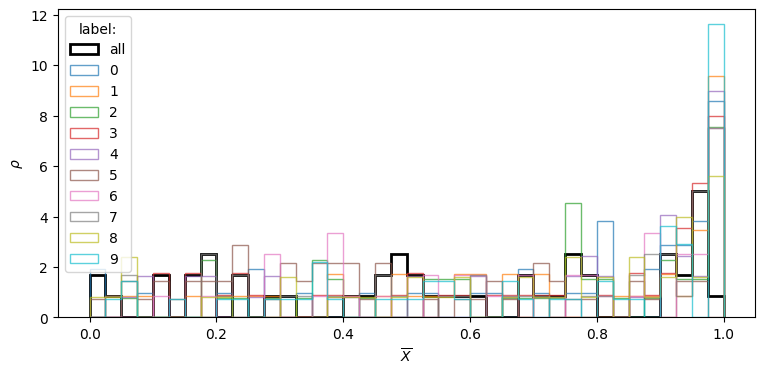

In [61]:
fig, ax = plt.subplots(figsize=(9,4))
bins = np.linspace(0., 1., 41)
for ikey, key in enumerate(C):
    if key == "all":
        color = "black"
        linewidth = 2.
        alpha = 1.0
    else:
        color = colors[ikey-1]
        linewidth = 1.0
        alpha = 0.7
    ax.hist(
        stats[key]["mean"].reshape(-1), bins, density=True, 
        color=color, linewidth=linewidth, alpha=alpha, histtype="step", label=key
    )
ax.set_ylabel(r"$\rho$")
ax.set_xlabel(r"$\overline{X}$")
ax.legend(title="label:");